Missing Data

https://www.projectpro.io/recipes/impute-missing-values-with-means-in-python

In [86]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer


In [87]:
# membaca file & menampilkan data paling atas(head)
file_path = "student_performance_large_dataset.csv"
df = pd.read_csv(file_path, sep = ";")
df_new = pd.DataFrame()
df.head()



,Student_ID,Age,Gender,Study_Hours_per_Week,Preferred_Learning_Style,Online_Courses_Completed,Participation_in_Discussions,Assignment_Completion_Rate (%),Exam_Score (%),Attendance_Rate (%),Use_of_Educational_Tech,Self_Reported_Stress_Level,Time_Spent_on_Social_Media (hours/week),Sleep_Hours_per_Night,Final_Grade
0,S00001,18,Female,48,Kinesthetic,14,Yes,100,69,66,Yes,High,9,8,C
1,S00002,29,Female,30,Reading/Writing,20,No,71,40,57,Yes,Medium,28,8,D
2,S00003,20,Female,47,Kinesthetic,11,No,60,43,79,Yes,Low,13,7,D
3,S00004,23,Female,13,Auditory,0,Yes,63,70,60,Yes,Low,24,10,B
4,S00005,19,Female,24,Auditory,19,Yes,59,63,93,Yes,Medium,26,8,C


In [88]:
# Menampilkan jumlah missing values di setiap kolom
print(df.isna().sum())

Student_ID                                 0
Age                                        0
Gender                                     0
Study_Hours_per_Week                       0
Preferred_Learning_Style                   0
Online_Courses_Completed                   0
Participation_in_Discussions               0
Assignment_Completion_Rate (%)             0
Exam_Score (%)                             0
Attendance_Rate (%)                        0
Use_of_Educational_Tech                    0
Self_Reported_Stress_Level                 0
Time_Spent_on_Social_Media (hours/week)    0
Sleep_Hours_per_Night                      0
Final_Grade                                0
dtype: int64


In [89]:
# Menghitung total data
total_data = len(df)

# Menghitung persentase missing values
missing_percentage = (df.isna().sum() / total_data) * 100

# Menampilkan kolom dengan missing values beserta persentasenya
missing_data = pd.DataFrame({
    'Jumlah Missing Values': df.isna().sum(),
    'Persentase (%)': missing_percentage
})

print(missing_data[missing_data['Jumlah Missing Values'] > 0])


Empty DataFrame
Columns: [Jumlah Missing Values, Persentase (%)]
Index: []


In [90]:
# Mengimputasi kolom numerik dengan mean
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isna().sum() > 0:
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)

# Memeriksa kembali apakah masih ada missing values
print(df.isna().sum())


Student_ID                                 0
Age                                        0
Gender                                     0
Study_Hours_per_Week                       0
Preferred_Learning_Style                   0
Online_Courses_Completed                   0
Participation_in_Discussions               0
Assignment_Completion_Rate (%)             0
Exam_Score (%)                             0
Attendance_Rate (%)                        0
Use_of_Educational_Tech                    0
Self_Reported_Stress_Level                 0
Time_Spent_on_Social_Media (hours/week)    0
Sleep_Hours_per_Night                      0
Final_Grade                                0
dtype: int64


DATA TRANSFORMATION

https://www.visual-design.net/post/data-transformation-and-feature-engineering-in-python

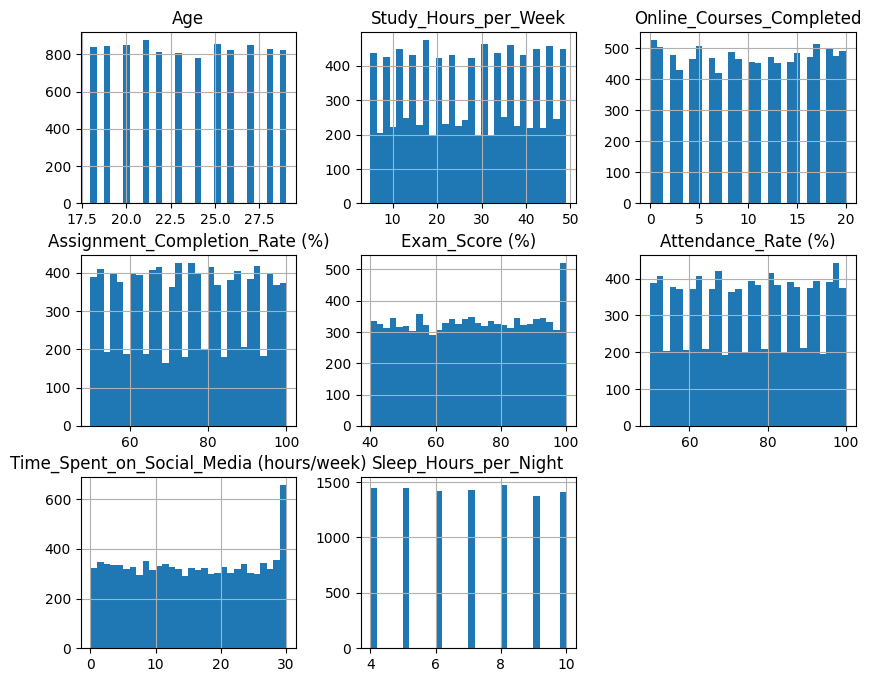

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribusi untuk semua kolom numerik
df.hist(figsize=(10, 8), bins=30)
plt.show()


In [92]:
# cek tipe data Kategori
print(df.dtypes)

Student_ID                                 object
Age                                         int64
Gender                                     object
Study_Hours_per_Week                        int64
Preferred_Learning_Style                   object
Online_Courses_Completed                    int64
Participation_in_Discussions               object
Assignment_Completion_Rate (%)              int64
Exam_Score (%)                              int64
Attendance_Rate (%)                         int64
Use_of_Educational_Tech                    object
Self_Reported_Stress_Level                 object
Time_Spent_on_Social_Media (hours/week)     int64
Sleep_Hours_per_Night                       int64
Final_Grade                                object
dtype: object


In [93]:
# Encoding Kategori
# mengubah format gender menjadi 'male' = 1 dan 'female' = 0, serta drop data gender other
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df = df[df['Gender'] != 'Other']

# mengubah format Participation_in_Discussions,Use_of_Educational_Tech menjadi 'yes' = 1 dan 'no' = 0
df['Participation_in_Discussions'] = df['Participation_in_Discussions'].map({'Yes': 1, 'No': 0})
df['Use_of_Educational_Tech'] = df['Use_of_Educational_Tech'].map({'Yes': 1, 'No': 0})

print(df.dtypes)

Student_ID                                  object
Age                                          int64
Gender                                     float64
Study_Hours_per_Week                         int64
Preferred_Learning_Style                    object
Online_Courses_Completed                     int64
Participation_in_Discussions                 int64
Assignment_Completion_Rate (%)               int64
Exam_Score (%)                               int64
Attendance_Rate (%)                          int64
Use_of_Educational_Tech                      int64
Self_Reported_Stress_Level                  object
Time_Spent_on_Social_Media (hours/week)      int64
Sleep_Hours_per_Night                        int64
Final_Grade                                 object
dtype: object


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_new = df.copy()
numerical_cols = ['Age', 'Assignment_Completion_Rate (%)', 'Attendance_Rate (%)', 'Time_Spent_on_Social_Media (hours/week)']  
df_new[numerical_cols] = scaler.fit_transform(df_new[numerical_cols])


In [95]:
print(df_new[numerical_cols].head())  # Menampilkan 5 data teratas setelah scaling

        Age  Assignment_Completion_Rate (%)  Attendance_Rate (%)  \
0 -1.582639                        1.708927            -0.616001   
1  1.594887                       -0.267263            -1.226232   
2 -1.004907                       -1.016852             0.265444   
3 -0.138309                       -0.812418            -1.022822   
4 -1.293773                       -1.084996             1.214692   

   Time_Spent_on_Social_Media (hours/week)  
0                                -0.657989  
1                                 1.447930  
2                                -0.214638  
3                                 1.004579  
4                                 1.226255  


In [96]:
print(df_new[numerical_cols].describe())

                Age  Assignment_Completion_Rate (%)  Attendance_Rate (%)  \
count  1.000000e+04                    1.000000e+04         1.000000e+04   
mean   9.805490e-17                    2.103206e-16         1.971756e-16   
std    1.000050e+00                    1.000050e+00         1.000050e+00   
min   -1.582639e+00                   -1.698297e+00        -1.700856e+00   
25%   -1.004907e+00                   -8.805630e-01        -8.872148e-01   
50%   -1.383090e-01                    5.315269e-03        -5.770073e-03   
75%    1.017155e+00                    8.911935e-01         8.756747e-01   
max    1.594887e+00                    1.708927e+00         1.689316e+00   

       Time_Spent_on_Social_Media (hours/week)  
count                             1.000000e+04  
mean                             -7.567280e-17  
std                               1.000050e+00  
min                              -1.655530e+00  
25%                              -8.796647e-01  
50%                  

In [97]:
print(df['Assignment_Completion_Rate (%)'].describe())


count    10000.000000
mean        74.922000
std         14.675437
min         50.000000
25%         62.000000
50%         75.000000
75%         88.000000
max        100.000000
Name: Assignment_Completion_Rate (%), dtype: float64


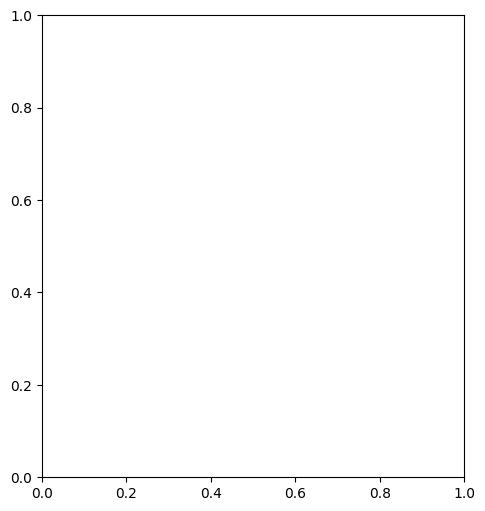

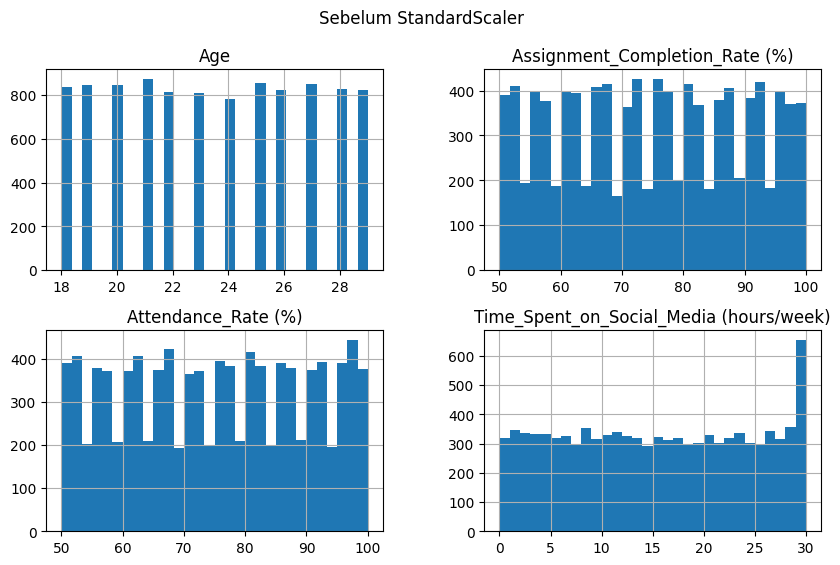

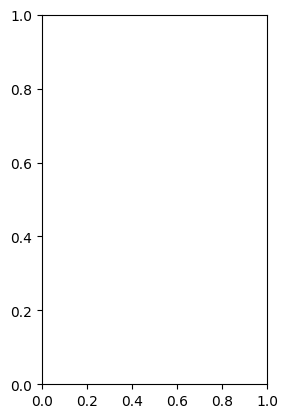

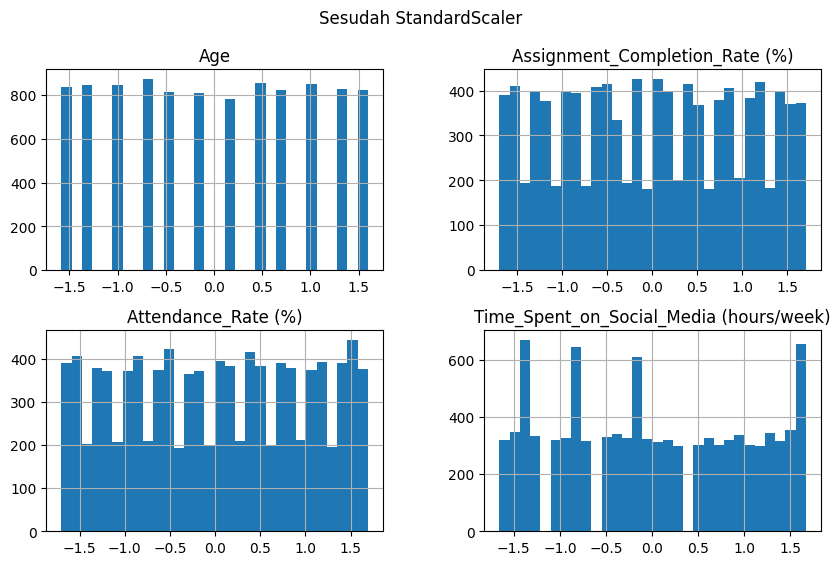

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Sebelum scaling (gunakan df asli sebelum diubah)
plt.subplot(1, 2, 1)
df[numerical_cols].hist(figsize=(10, 6), bins=30)
plt.suptitle("Sebelum StandardScaler") 
plt.show()


# Sesudah scaling
plt.subplot(1, 2, 2)
df_new[numerical_cols].hist(figsize=(10, 6), bins=30)
plt.suptitle("Sesudah StandardScaler")

plt.show()


In [99]:
# log transformation
df['Exam_Score (%)'] = np.log1p(df['Exam_Score (%)'])  
print(df[['Exam_Score (%)']].head())

   Exam_Score (%)
0        4.248495
1        3.713572
2        3.784190
3        4.262680
4        4.158883


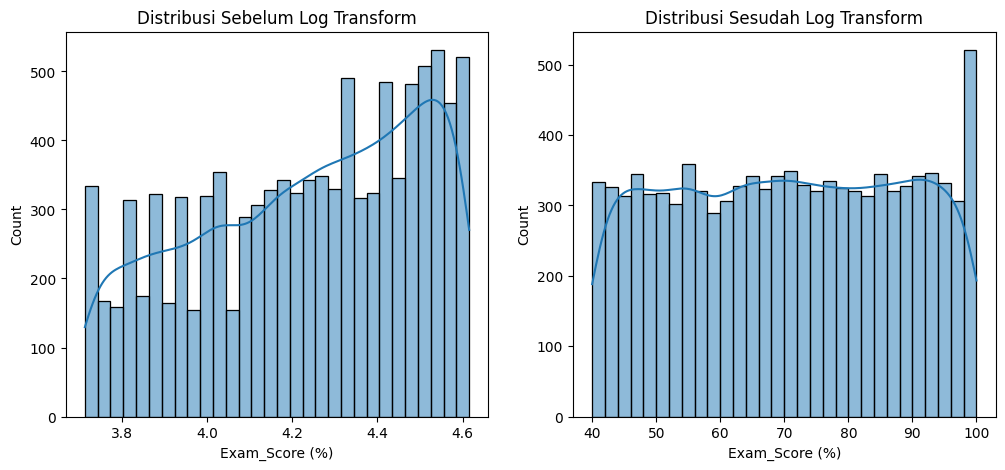

In [100]:
import seaborn as sns

plt.figure(figsize=(12, 5))

# Sebelum transformasi
plt.subplot(1, 2, 1)
sns.histplot(df['Exam_Score (%)'], bins=30, kde=True)
plt.title("Distribusi Sebelum Log Transform")

# Sesudah transformasi
plt.subplot(1, 2, 2)
sns.histplot(df_new['Exam_Score (%)'], bins=30, kde=True)
plt.title("Distribusi Sesudah Log Transform")

plt.show()


In [101]:
# handling outliers
df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(lower=df['Exam_Score (%)'].quantile(0.05), upper=df['Exam_Score (%)'].quantile(0.95))

In [102]:
print("Sebelum handling outliers:")
print(df['Exam_Score (%)'].describe())

# Handling outliers
df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(lower=df['Exam_Score (%)'].quantile(0.05), upper=df['Exam_Score (%)'].quantile(0.95))

print("\nSesudah handling outliers:")
print(df['Exam_Score (%)'].describe())


Sebelum handling outliers:
count    10000.000000
mean         4.233271
std          0.257176
min          3.761200
25%          4.025352
50%          4.262680
75%          4.454347
max          4.595120
Name: Exam_Score (%), dtype: float64

Sesudah handling outliers:
count    10000.000000
mean         4.233271
std          0.257176
min          3.761200
25%          4.025352
50%          4.262680
75%          4.454347
max          4.595120
Name: Exam_Score (%), dtype: float64


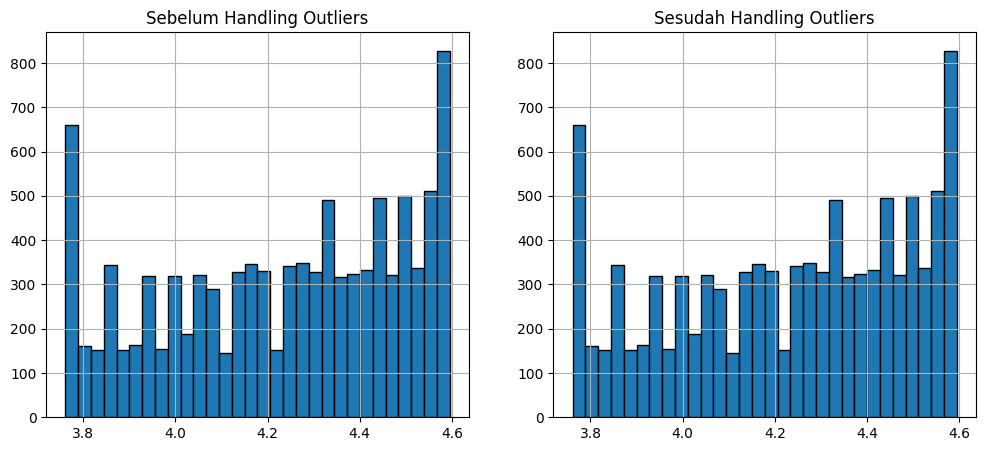

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Sebelum handling outliers
plt.subplot(1, 2, 1)
df['Exam_Score (%)'].hist(bins=30, edgecolor='black')
plt.title("Sebelum Handling Outliers")

# Sesudah handling outliers
df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(lower=df['Exam_Score (%)'].quantile(0.05), upper=df['Exam_Score (%)'].quantile(0.95))

plt.subplot(1, 2, 2)
df['Exam_Score (%)'].hist(bins=30, edgecolor='black')
plt.title("Sesudah Handling Outliers")

plt.show()


Q5: 3.7612001156935624
Q95: 4.59511985013459


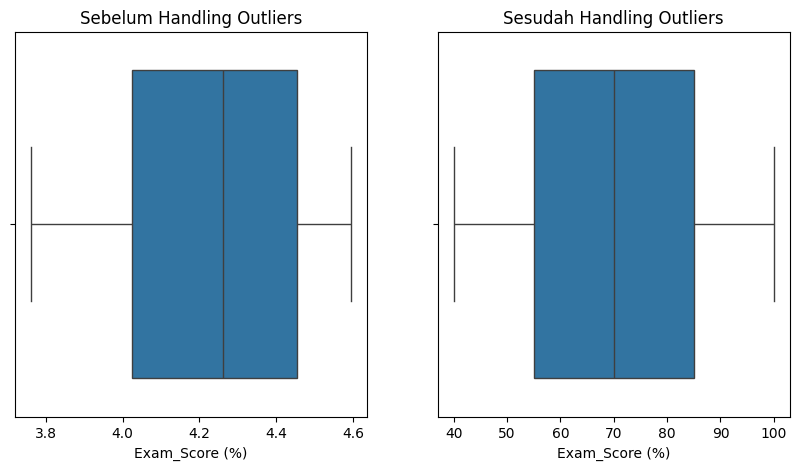

In [104]:
print("Q5:", df['Exam_Score (%)'].quantile(0.05))
print("Q95:", df['Exam_Score (%)'].quantile(0.95))

# Visualisasi Boxplot sebelum dan sesudah
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['Exam_Score (%)'])
plt.title("Sebelum Handling Outliers")

plt.subplot(1,2,2)
sns.boxplot(x=df_new['Exam_Score (%)'])
plt.title("Sesudah Handling Outliers")

plt.show()


In [105]:
print("Sebelum handling outliers:")
print(df['Exam_Score (%)'].describe())

# Debugging tambahan sebelum handling
print(f"Lower Bound (5%): {df['Exam_Score (%)'].quantile(0.05)}")
print(f"Upper Bound (95%): {df['Exam_Score (%)'].quantile(0.95)}")

# Handling outliers dengan clipping
df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(
    lower=df['Exam_Score (%)'].quantile(0.05),
    upper=df['Exam_Score (%)'].quantile(0.95)
)

print("\nSesudah handling outliers:")
print(df['Exam_Score (%)'].describe())


Sebelum handling outliers:
count    10000.000000
mean         4.233271
std          0.257176
min          3.761200
25%          4.025352
50%          4.262680
75%          4.454347
max          4.595120
Name: Exam_Score (%), dtype: float64
Lower Bound (5%): 3.7612001156935624
Upper Bound (95%): 4.59511985013459

Sesudah handling outliers:
count    10000.000000
mean         4.233271
std          0.257176
min          3.761200
25%          4.025352
50%          4.262680
75%          4.454347
max          4.595120
Name: Exam_Score (%), dtype: float64


In [106]:
lower_bound = df['Exam_Score (%)'].quantile(0.01)
upper_bound = df['Exam_Score (%)'].quantile(0.99)
df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(lower=lower_bound, upper=upper_bound)


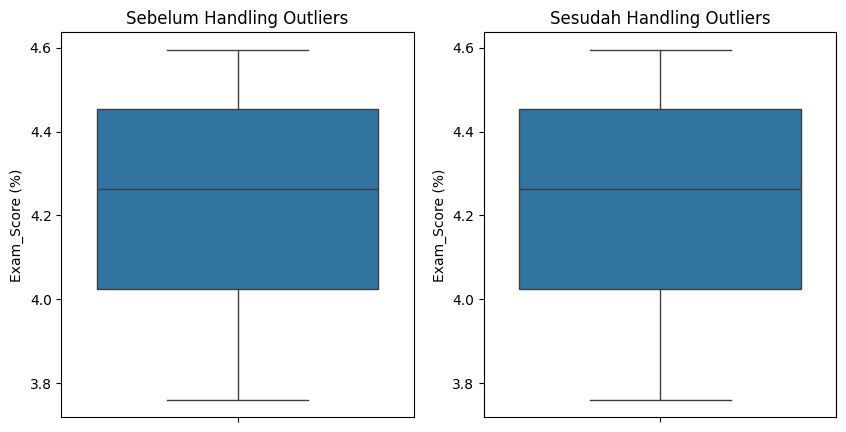

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.boxplot(y=df['Exam_Score (%)'], ax=axes[0])
axes[0].set_title("Sebelum Handling Outliers")

sns.boxplot(y=df['Exam_Score (%)'], ax=axes[1])
axes[1].set_title("Sesudah Handling Outliers")

plt.show()


In [108]:
Q1 = df['Exam_Score (%)'].quantile(0.25)
Q3 = df['Exam_Score (%)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(lower=lower_bound, upper=upper_bound)


In [109]:
lower_bound = df['Exam_Score (%)'].quantile(0.01)
upper_bound = df['Exam_Score (%)'].quantile(0.99)
df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(lower=lower_bound, upper=upper_bound)


In [110]:
outliers_before = ((df['Exam_Score (%)'] < lower_bound) | (df['Exam_Score (%)'] > upper_bound)).sum()
print(f"Jumlah outlier sebelum: {outliers_before}")

df['Exam_Score (%)'] = df['Exam_Score (%)'].clip(lower=lower_bound, upper=upper_bound)

outliers_after = ((df['Exam_Score (%)'] < lower_bound) | (df['Exam_Score (%)'] > upper_bound)).sum()
print(f"Jumlah outlier setelah: {outliers_after}")


Jumlah outlier sebelum: 0
Jumlah outlier setelah: 0


DATA SCALLING & NORMALISASI

https://wellsr.com/python/data-scaling-and-normalization-with-python/

In [111]:
numerical_cols = ['Age', 'Assignment_Completion_Rate (%)', 'Participation_in_Discussions', 'Exam_Score (%)']

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Cek hasil scaling
print(df.head())


  Student_ID       Age  Gender  Study_Hours_per_Week Preferred_Learning_Style  \
0     S00001 -1.582639     0.0                    48              Kinesthetic   
1     S00002  1.594887     0.0                    30          Reading/Writing   
2     S00003 -1.004907     0.0                    47              Kinesthetic   
3     S00004 -0.138309     0.0                    13                 Auditory   
4     S00005 -1.293773     0.0                    24                 Auditory   

   Online_Courses_Completed  Participation_in_Discussions  \
0                        14                      0.817177   
1                        20                     -1.223725   
2                        11                     -1.223725   
3                         0                      0.817177   
4                        19                      0.817177   

   Assignment_Completion_Rate (%)  Exam_Score (%)  Attendance_Rate (%)  \
0                        1.708927        0.059202                   66  

In [113]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Cek hasil scaling
print(df.head())


  Student_ID       Age  Gender  Study_Hours_per_Week Preferred_Learning_Style  \
0     S00001  0.000000     0.0                    48              Kinesthetic   
1     S00002  1.000000     0.0                    30          Reading/Writing   
2     S00003  0.181818     0.0                    47              Kinesthetic   
3     S00004  0.454545     0.0                    13                 Auditory   
4     S00005  0.090909     0.0                    24                 Auditory   

   Online_Courses_Completed  Participation_in_Discussions  \
0                        14                           1.0   
1                        20                           0.0   
2                        11                           0.0   
3                         0                           1.0   
4                        19                           1.0   

   Assignment_Completion_Rate (%)  Exam_Score (%)  Attendance_Rate (%)  \
0                            1.00        0.584343                   66  

In [114]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l1')
df[numerical_cols] = normalizer.fit_transform(df[numerical_cols])

print(df.head())


  Student_ID       Age  Gender  Study_Hours_per_Week Preferred_Learning_Style  \
0     S00001  0.000000     0.0                    48              Kinesthetic   
1     S00002  0.704225     0.0                    30          Reading/Writing   
2     S00003  0.444124     0.0                    47              Kinesthetic   
3     S00004  0.196272     0.0                    13                 Auditory   
4     S00005  0.052014     0.0                    24                 Auditory   

   Online_Courses_Completed  Participation_in_Discussions  \
0                        14                      0.386946   
1                        20                      0.000000   
2                        11                      0.000000   
3                         0                      0.431798   
4                        19                      0.572150   

   Assignment_Completion_Rate (%)  Exam_Score (%)  Attendance_Rate (%)  \
0                        0.386946        0.226109                   66  

In [115]:
normalizer = Normalizer(norm='l2')
df[numerical_cols] = normalizer.fit_transform(df[numerical_cols])

print(df.head())


  Student_ID       Age  Gender  Study_Hours_per_Week Preferred_Learning_Style  \
0     S00001  0.000000     0.0                    48              Kinesthetic   
1     S00002  0.921982     0.0                    30          Reading/Writing   
2     S00003  0.669201     0.0                    47              Kinesthetic   
3     S00004  0.355392     0.0                    13                 Auditory   
4     S00005  0.080730     0.0                    24                 Auditory   

   Online_Courses_Completed  Participation_in_Discussions  \
0                        14                      0.653517   
1                        20                      0.000000   
2                        11                      0.000000   
3                         0                      0.781862   
4                        19                      0.888027   

   Assignment_Completion_Rate (%)  Exam_Score (%)  Attendance_Rate (%)  \
0                        0.653517        0.381878                   66  

In [116]:
df.to_csv("student_performance_preprocessed.csv", index=False)